# Task 4 — Model Creation
### Formative 2: Multimodal Data Preprocessing

Three models, trained on the outputs of Tasks 1–3:

1. **Facial Recognition Model** — identifies *which* authorized member a face image belongs to (`image_features.csv`)
2. **Voiceprint Verification Model** — identifies *which* authorized member a voice recording belongs to (`audio_features.csv`)
3. **Product Recommendation Model** — predicts purchased `product_category` from transaction + social features (`merged_customer_dataset.csv`)

> **Data note:** `image_features.csv` / `audio_features.csv` still contain the **synthetic placeholder identities** from Tasks 2–3 (`EXAMPLE_MEMBER`, `EXAMPLE_MEMBER_2`) plus one held-out **`UNAUTHORIZED_ATTEMPT`** probe sample, generated purely so this notebook's code, thresholds, and evaluation logic can be verified end-to-end. Once your group's real photos/recordings replace them, `member` becomes real teammate names and the same code retrains on real data with no changes needed. The product recommendation model, in contrast, is trained on the **real merged dataset** from Task 1.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style('whitegrid')
os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42


## 1. Facial Recognition Model

Trained only on **authorized** identities. `UNAUTHORIZED_ATTEMPT` is deliberately excluded from training — an open-set "unknown" identity should never appear as a training class, or the model would just learn to recognize a specific impostor rather than to detect *any* unrecognized face. It's used later purely as an inference-time probe.


In [2]:
image_features = pd.read_csv('image_features.csv')
UNAUTHORIZED_LABEL = 'UNAUTHORIZED_ATTEMPT'

face_train_pool = image_features[image_features['member'] != UNAUTHORIZED_LABEL].copy()
face_unauthorized_probe = image_features[image_features['member'] == UNAUTHORIZED_LABEL].copy()

id_cols = ['member', 'expression', 'augmentation', 'source_file', 'width', 'height']
face_feature_cols = [c for c in image_features.columns if c not in id_cols]

print('Authorized identities:', face_train_pool['member'].unique())
print('Training pool shape:', face_train_pool.shape)
print('Unauthorized probe rows (held out):', face_unauthorized_probe.shape)


Authorized identities: <StringArray>
['EXAMPLE_MEMBER', 'EXAMPLE_MEMBER_2']
Length: 2, dtype: str
Training pool shape: (24, 90)
Unauthorized probe rows (held out): (4, 90)


In [3]:
le_face = LabelEncoder()
X_face = face_train_pool[face_feature_cols].values
y_face = le_face.fit_transform(face_train_pool['member'])

X_train, X_test, y_train, y_test = train_test_split(
    X_face, y_face, test_size=0.3, random_state=RANDOM_STATE, stratify=y_face
)

face_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
face_model.fit(X_train, y_train)

y_pred = face_model.predict(X_test)
y_proba = face_model.predict_proba(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('F1 (macro):', round(f1_score(y_test, y_pred, average='macro'), 3))
print('Log loss:', round(log_loss(y_test, y_proba, labels=list(range(len(le_face.classes_)))), 3))
print()
print(classification_report(y_test, y_pred, target_names=le_face.classes_))


Accuracy: 1.0
F1 (macro): 1.0
Log loss: 0.076

                  precision    recall  f1-score   support

  EXAMPLE_MEMBER       1.00      1.00      1.00         4
EXAMPLE_MEMBER_2       1.00      1.00      1.00         4

        accuracy                           1.00         8
       macro avg       1.00      1.00      1.00         8
    weighted avg       1.00      1.00      1.00         8



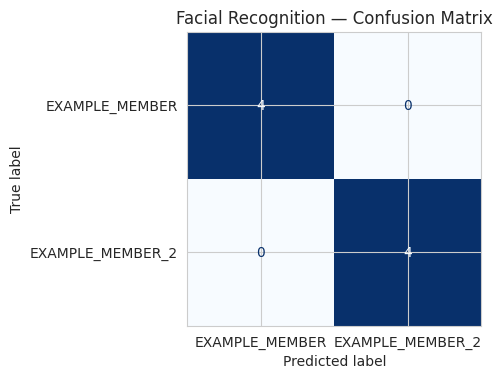

In [4]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(le_face.classes_))))
disp = ConfusionMatrixDisplay(cm, display_labels=le_face.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Facial Recognition — Confusion Matrix')
plt.tight_layout()
plt.savefig('face_confusion_matrix.png')
plt.show()


### Open-set rejection (the "is this face even one of our members" check)

A plain classifier always outputs *some* class, even for a face it has never seen — so identity prediction alone can't reject strangers. Two signals are combined instead:

- **Confidence threshold** — reject if the top predicted-class probability is low.
- **Centroid distance threshold** — build a mean feature vector ("centroid") per authorized member from training data; reject if the new sample is unusually far from *every* centroid, using each member's own training-sample spread to define "unusual" (95th percentile distance).

A sample is accepted only if it clears **both** checks.


In [5]:
# Build per-class centroids and each class's own training-distance spread
centroids = {}
distance_thresholds = {}
for class_idx in np.unique(y_train):
    class_points = X_train[y_train == class_idx]
    centroid = class_points.mean(axis=0)
    centroids[class_idx] = centroid
    dists = np.linalg.norm(class_points - centroid, axis=1)
    distance_thresholds[class_idx] = np.percentile(dists, 95)

def authenticate_face(feature_vector, model, le, centroids, distance_thresholds, proba_threshold=0.5):
    feature_vector = np.asarray(feature_vector).reshape(1, -1)
    proba = model.predict_proba(feature_vector)[0]
    pred_idx = int(np.argmax(proba))
    confidence = proba[pred_idx]

    dist_to_centroid = np.linalg.norm(feature_vector[0] - centroids[pred_idx])
    within_distance = dist_to_centroid <= distance_thresholds[pred_idx]

    if confidence >= proba_threshold and within_distance:
        return {'authorized': True, 'member': le.inverse_transform([pred_idx])[0],
                'confidence': float(confidence), 'distance': float(dist_to_centroid)}
    return {'authorized': False, 'member': None,
            'confidence': float(confidence), 'distance': float(dist_to_centroid)}

# Sanity check: a held-out *authorized* test sample should pass
sample_idx = 0
result = authenticate_face(X_test[sample_idx], face_model, le_face, centroids, distance_thresholds)
print('Authorized test sample ->', result, '| true identity:', le_face.inverse_transform([y_test[sample_idx]])[0])

# The actual open-set test: the UNAUTHORIZED_ATTEMPT probe should be rejected
probe_vec = face_unauthorized_probe[face_feature_cols].values[0]
probe_result = authenticate_face(probe_vec, face_model, le_face, centroids, distance_thresholds)
print('Unauthorized probe ->', probe_result)


Authorized test sample -> {'authorized': True, 'member': 'EXAMPLE_MEMBER', 'confidence': 0.95, 'distance': 5.104295686808634} | true identity: EXAMPLE_MEMBER
Unauthorized probe -> {'authorized': False, 'member': None, 'confidence': 0.585, 'distance': 19.965557918647026}


In [6]:
joblib.dump({'model': face_model, 'label_encoder': le_face, 'centroids': centroids,
             'distance_thresholds': distance_thresholds, 'feature_cols': face_feature_cols},
            'models/face_recognition_model.joblib')
print('Saved models/face_recognition_model.joblib')


Saved models/face_recognition_model.joblib


## 2. Voiceprint Verification Model

Same open-set structure as the facial model: trained only on authorized voices, `UNAUTHORIZED_ATTEMPT` held out as a probe.


In [7]:
audio_features = pd.read_csv('audio_features.csv')

voice_train_pool = audio_features[audio_features['member'] != UNAUTHORIZED_LABEL].copy()
voice_unauthorized_probe = audio_features[audio_features['member'] == UNAUTHORIZED_LABEL].copy()

voice_id_cols = ['member', 'phrase', 'augmentation', 'source_file']
voice_feature_cols = [c for c in audio_features.columns if c not in voice_id_cols]

print('Authorized voices:', voice_train_pool['member'].unique())
print('Training pool shape:', voice_train_pool.shape)
print('Unauthorized probe rows (held out):', voice_unauthorized_probe.shape)


Authorized voices: <StringArray>
['EXAMPLE_MEMBER', 'EXAMPLE_MEMBER_2']
Length: 2, dtype: str
Training pool shape: (16, 35)
Unauthorized probe rows (held out): (4, 35)


In [8]:
le_voice = LabelEncoder()
X_voice = voice_train_pool[voice_feature_cols].values
y_voice = le_voice.fit_transform(voice_train_pool['member'])

Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    X_voice, y_voice, test_size=0.3, random_state=RANDOM_STATE, stratify=y_voice
)

voice_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
voice_model.fit(Xv_train, yv_train)

yv_pred = voice_model.predict(Xv_test)
yv_proba = voice_model.predict_proba(Xv_test)

print('Accuracy:', round(accuracy_score(yv_test, yv_pred), 3))
print('F1 (macro):', round(f1_score(yv_test, yv_pred, average='macro'), 3))
print('Log loss:', round(log_loss(yv_test, yv_proba, labels=list(range(len(le_voice.classes_)))), 3))
print()
print(classification_report(yv_test, yv_pred, target_names=le_voice.classes_))


Accuracy: 0.8
F1 (macro): 0.8
Log loss: 0.304

                  precision    recall  f1-score   support

  EXAMPLE_MEMBER       1.00      0.67      0.80         3
EXAMPLE_MEMBER_2       0.67      1.00      0.80         2

        accuracy                           0.80         5
       macro avg       0.83      0.83      0.80         5
    weighted avg       0.87      0.80      0.80         5



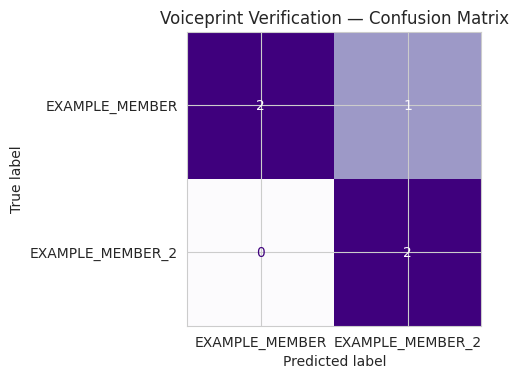

In [9]:
cm_v = confusion_matrix(yv_test, yv_pred, labels=list(range(len(le_voice.classes_))))
disp_v = ConfusionMatrixDisplay(cm_v, display_labels=le_voice.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp_v.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Voiceprint Verification — Confusion Matrix')
plt.tight_layout()
plt.savefig('voice_confusion_matrix.png')
plt.show()


In [10]:
voice_centroids = {}
voice_distance_thresholds = {}
for class_idx in np.unique(yv_train):
    class_points = Xv_train[yv_train == class_idx]
    centroid = class_points.mean(axis=0)
    voice_centroids[class_idx] = centroid
    dists = np.linalg.norm(class_points - centroid, axis=1)
    voice_distance_thresholds[class_idx] = np.percentile(dists, 95)

def authenticate_voice(feature_vector, model, le, centroids, distance_thresholds, proba_threshold=0.5):
    feature_vector = np.asarray(feature_vector).reshape(1, -1)
    proba = model.predict_proba(feature_vector)[0]
    pred_idx = int(np.argmax(proba))
    confidence = proba[pred_idx]
    dist_to_centroid = np.linalg.norm(feature_vector[0] - centroids[pred_idx])
    within_distance = dist_to_centroid <= distance_thresholds[pred_idx]
    if confidence >= proba_threshold and within_distance:
        return {'authorized': True, 'member': le.inverse_transform([pred_idx])[0],
                'confidence': float(confidence), 'distance': float(dist_to_centroid)}
    return {'authorized': False, 'member': None, 'confidence': float(confidence), 'distance': float(dist_to_centroid)}

sample_idx = 0
result = authenticate_voice(Xv_test[sample_idx], voice_model, le_voice, voice_centroids, voice_distance_thresholds)
print('Authorized test sample ->', result, '| true identity:', le_voice.inverse_transform([yv_test[sample_idx]])[0])

probe_vec = voice_unauthorized_probe[voice_feature_cols].values[0]
probe_result = authenticate_voice(probe_vec, voice_model, le_voice, voice_centroids, voice_distance_thresholds)
print('Unauthorized probe ->', probe_result)


Authorized test sample -> {'authorized': True, 'member': 'EXAMPLE_MEMBER', 'confidence': 0.73, 'distance': 519.6206409236921} | true identity: EXAMPLE_MEMBER
Unauthorized probe -> {'authorized': False, 'member': None, 'confidence': 0.58, 'distance': 818.9574272365159}


In [11]:
joblib.dump({'model': voice_model, 'label_encoder': le_voice, 'centroids': voice_centroids,
             'distance_thresholds': voice_distance_thresholds, 'feature_cols': voice_feature_cols},
            'models/voice_verification_model.joblib')
print('Saved models/voice_verification_model.joblib')


Saved models/voice_verification_model.joblib


## 3. Product Recommendation Model

Trained on the **real** merged dataset from Task 1 (transactions + aggregated social features). Target: `product_category`. Two candidate models are compared; the better one is saved.


In [12]:
merged = pd.read_csv('merged_customer_dataset.csv')

le_platform = LabelEncoder()
merged['dominant_platform_code'] = le_platform.fit_transform(merged['dominant_platform'])

product_feature_cols = [
    'purchase_amount', 'customer_rating', 'avg_engagement_score', 'avg_purchase_interest_score',
    'avg_sentiment_score', 'platform_diversity', 'num_social_interactions',
    'purchase_month', 'is_high_value_purchase', 'dominant_platform_code'
]

le_product = LabelEncoder()
X_prod = merged[product_feature_cols].values
y_prod = le_product.fit_transform(merged['product_category'])

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_prod, y_prod, test_size=0.25, random_state=RANDOM_STATE, stratify=y_prod
)

print('Train shape:', Xp_train.shape, '| Test shape:', Xp_test.shape)
print('Classes:', list(le_product.classes_))


Train shape: (87, 10) | Test shape: (30, 10)
Classes: ['Books', 'Clothing', 'Electronics', 'Groceries', 'Sports']


In [13]:
candidates = {
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    'LogisticRegression': LogisticRegression(max_iter=1000),
}

results = {}
for name, clf in candidates.items():
    clf.fit(Xp_train, yp_train)
    pred = clf.predict(Xp_test)
    proba = clf.predict_proba(Xp_test)
    results[name] = {
        'model': clf,
        'accuracy': accuracy_score(yp_test, pred),
        'f1_macro': f1_score(yp_test, pred, average='macro'),
        'log_loss': log_loss(yp_test, proba, labels=list(range(len(le_product.classes_)))),
    }

results_df = pd.DataFrame({k: {m: v for m, v in r.items() if m != 'model'} for k, r in results.items()}).T
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,f1_macro,log_loss
RandomForest,0.166667,0.149744,1.864845
LogisticRegression,0.133333,0.111111,2.090699


**Note on these numbers:** with 117 merged rows split across 5 product categories, the test set has roughly 5–6 examples per class — small enough that these metrics are a sanity check of the pipeline, not a reliable estimate of real-world performance. More transaction history per customer would be needed for a production-grade recommendation model.

Selected model: RandomForest
              precision    recall  f1-score   support

       Books       0.00      0.00      0.00         5
    Clothing       0.29      0.33      0.31         6
 Electronics       0.00      0.00      0.00         7
   Groceries       0.25      0.40      0.31         5
      Sports       0.12      0.14      0.13         7

    accuracy                           0.17        30
   macro avg       0.13      0.18      0.15        30
weighted avg       0.13      0.17      0.14        30



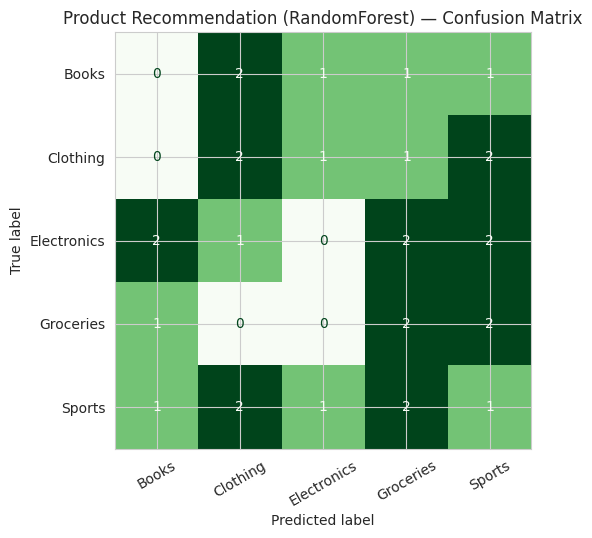

In [14]:
best_name = results_df['accuracy'].idxmax()
best_model = results[best_name]['model']
print('Selected model:', best_name)

pred_best = best_model.predict(Xp_test)
print(classification_report(yp_test, pred_best, target_names=le_product.classes_))

cm_p = confusion_matrix(yp_test, pred_best, labels=list(range(len(le_product.classes_))))
disp_p = ConfusionMatrixDisplay(cm_p, display_labels=le_product.classes_)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
disp_p.plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=30)
ax.set_title(f'Product Recommendation ({best_name}) — Confusion Matrix')
plt.tight_layout()
plt.savefig('product_confusion_matrix.png')
plt.show()


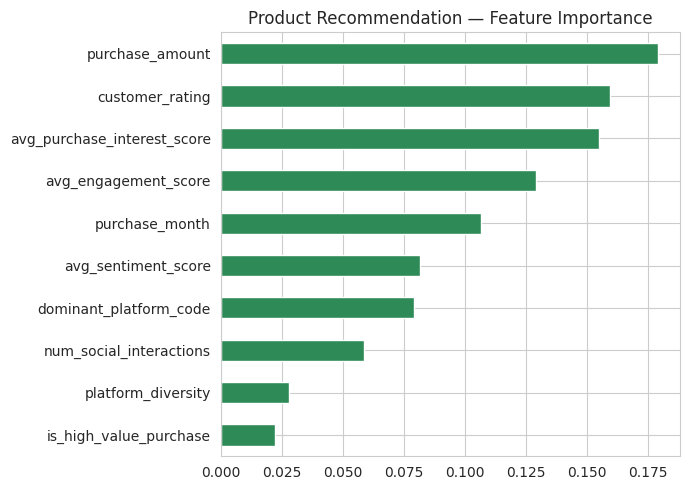

In [15]:
if best_name == 'RandomForest':
    importances = pd.Series(best_model.feature_importances_, index=product_feature_cols).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    importances.plot.barh(ax=ax, color='seagreen')
    ax.set_title('Product Recommendation — Feature Importance')
    plt.tight_layout()
    plt.savefig('product_feature_importance.png')
    plt.show()


In [16]:
joblib.dump({'model': best_model, 'label_encoder': le_product, 'platform_encoder': le_platform,
             'feature_cols': product_feature_cols, 'model_name': best_name},
            'models/product_recommendation_model.joblib')
print(f'Saved models/product_recommendation_model.joblib (best model: {best_name})')


Saved models/product_recommendation_model.joblib (best model: RandomForest)


## Summary

All three models are saved under `models/` and ready to be loaded by the Task 5 CLI app.

**Caveat to repeat in your report:** the facial-recognition and voiceprint metrics above are measured on *synthetic placeholder data* (cartoon faces / generated tones), so the near-perfect scores reflect how easy that placeholder data is to separate — not real-world face/voice recognition performance. Re-run this notebook once your group's real photos and recordings replace the placeholder folders; the code needs no changes, only real data.

In [17]:
summary = pd.DataFrame([
    {
        'model': 'Facial Recognition',
        'type': 'RandomForest',
        'trained_on': 'placeholder image features (Tasks 2)',
        'accuracy': round(accuracy_score(y_test, y_pred), 3),
        'f1_macro': round(f1_score(y_test, y_pred, average='macro'), 3),
        'log_loss': round(log_loss(y_test, y_proba, labels=list(range(len(le_face.classes_)))), 3),
    },
    {
        'model': 'Voiceprint Verification',
        'type': 'RandomForest',
        'trained_on': 'placeholder audio features (Task 3)',
        'accuracy': round(accuracy_score(yv_test, yv_pred), 3),
        'f1_macro': round(f1_score(yv_test, yv_pred, average='macro'), 3),
        'log_loss': round(log_loss(yv_test, yv_proba, labels=list(range(len(le_voice.classes_)))), 3),
    },
    {
        'model': 'Product Recommendation',
        'type': best_name,
        'trained_on': 'real merged dataset (Task 1)',
        'accuracy': round(results[best_name]['accuracy'], 3),
        'f1_macro': round(results[best_name]['f1_macro'], 3),
        'log_loss': round(results[best_name]['log_loss'], 3),
    },
])
summary


,model,type,trained_on,accuracy,f1_macro,log_loss
0,Facial Recognition,RandomForest,placeholder image features (Tasks 2),1.000,1.00,0.076
1,Voiceprint Verification,RandomForest,placeholder audio features (Task 3),0.800,0.80,0.304
2,Product Recommendation,RandomForest,real merged dataset (Task 1),0.167,0.15,1.865
